# 실습 3. SVR 회귀

California Housing 데이터를 사용해 SVR 회귀 모델의 학습, 평가, 예측, 튜닝 흐름을 연습함.

- feature와 target을 각각 스케일링함.
- linear, poly, rbf kernel의 회귀 성능을 비교함.
- 새로운 샘플의 주택 가격을 예측함.
- `GridSearchCV`로 RBF SVR의 하이퍼파라미터 후보를 비교함.


In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

data_path = Path('../data/california_housing.csv')
housing_df = pd.read_csv(data_path)

# 실습 시간을 줄이기 위해 샘플 일부를 사용함.
housing_sample_df = housing_df.sample(n=1200, random_state=42).reset_index(drop=True)

housing_X = housing_sample_df.drop('MedHouseVal', axis=1)
housing_y = housing_sample_df['MedHouseVal']

print(housing_sample_df.shape)
display(housing_sample_df.head())
display(housing_sample_df.describe().round(3))


(1200, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000,1200.000
mean,3.904,28.940,5.366,1.078,1407.419,3.002,35.568,-119.500,2.082
std,2.029,12.331,1.698,0.235,1033.236,2.442,2.136,1.977,1.167
min,0.683,2.000,2.097,0.500,8.000,1.313,32.550,-124.190,0.300
25%,2.571,19.000,4.424,1.005,800.750,2.446,33.930,-121.700,1.219
50%,3.465,30.000,5.185,1.047,1159.500,2.833,34.215,-118.450,1.799
75%,4.713,37.000,6.033,1.098,1708.250,3.309,37.670,-118.028,2.657
max,15.000,52.000,36.075,5.274,8733.000,83.171,41.790,-114.590,5.000


## 문제 1. 학습/평가 데이터 분리와 스케일링

`housing_X`, `housing_y`를 학습/평가 데이터로 나누고 feature와 target을 각각 스케일링함.

힌트:
- `train_test_split()`
- `StandardScaler()`
- target은 `to_numpy().reshape(-1, 1)`로 2차원 변환 후 스케일링
- 모델 학습에는 `housing_y_train_scaled.ravel()` 사용

### 실행 결과
```text
X_train: (960, 8)
X_test: (240, 8)
y_train_scaled: (960,)
```


In [14]:
housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.2,
    random_state=42
)

housing_X_scaler = StandardScaler()

housing_X_train_scaled = housing_X_scaler.fit_transform(housing_X_train)
housing_X_test_scaled = housing_X_scaler.transform(housing_X_test)

housing_y_scaler = StandardScaler()

housing_y_train_scaled = housing_y_scaler.fit_transform(
    housing_y_train.to_numpy().reshape(-1, 1)
).ravel()

housing_y_test_scaled = housing_y_scaler.transform(
    housing_y_test.to_numpy().reshape(-1, 1)
).ravel()

print("X_train: ", housing_X_train.shape)
print("x_test: ", housing_X_test.shape)
print("y_train_scaled: ", housing_y_train_scaled.shape)

X_train:  (960, 8)
x_test:  (240, 8)
y_train_scaled:  (960,)


## 문제 2. Kernel별 SVR 모델 학습과 평가

`linear`, `poly`, `rbf` kernel SVR을 각각 학습하고 평가셋 RMSE, MAE, R2를 비교함.

힌트:
- `SVR(kernel='linear')`
- `SVR(kernel='poly', degree=2)`
- `SVR(kernel='rbf')`
- 예측값은 `housing_y_scaler.inverse_transform()`으로 원래 단위로 복원

### 실행 결과
```text
kernel      RMSE       MAE        R2
2     rbf  0.686232  0.493047  0.660761
0  linear  0.696842  0.479657  0.650191
1    poly  1.000544  0.734170  0.278834
```


In [21]:
svr_models = {
    'liner': SVR(kernel='linear', C=1, epsilon=0.1),
    'ploy': SVR(kernel='poly', C=10, degree=2, epsilon=0.1),
    'rbf': SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1),
}

svr_results = []
trained_svr_models = {}

for name, model in svr_models.items():
    model.fit(housing_X_train_scaled, housing_y_train_scaled)
    trained_svr_models[name] = model

    pred_scaled = model.predict(housing_X_test_scaled).reshape(-1, 1)

    pred = housing_y_scaler.inverse_transform(pred_scaled).ravel()

    svr_results.append({
            'kernel': name,
            'R2': r2_score(housing_y_test, pred),
            'MAE': mean_absolute_error(housing_y_test, pred),
            'RMSE': root_mean_squared_error(housing_y_test, pred),
            'MSE': mean_squared_error(housing_y_test, pred),
            'support_vector_count': len(model.support_)
        })

svr_result_df = pd.DataFrame(svr_results)
display(svr_result_df)

best_svr_model = trained_svr_models['rbf']

,kernel,R2,MAE,RMSE,MSE,support_vector_count
0,liner,0.650191,0.479657,0.696842,0.485588,782
1,ploy,0.207906,0.743632,1.048592,1.099546,839
2,rbf,0.660729,0.493065,0.686265,0.470960,738


## 문제 3. 새로운 샘플 예측

문제 2에서 평가 성능이 가장 좋았던 모델로 평가 데이터 일부를 예측하고 실제값과 비교함.

힌트:
- `svr_result_df.iloc[0]['kernel']`
- `trained_svr_models[best_kernel]`
- `inverse_transform()`

### 실행 결과
```text
선택한 kernel: rbf

   actual  predicted
0   1.697      1.509
1   0.527      0.486
2   3.576      4.610
3   2.625      2.657
4   2.556      1.661
```


## 문제 4. `GridSearchCV`로 RBF SVR 튜닝

RBF SVR의 `C`, `epsilon`, `gamma` 후보를 교차검증으로 비교함.

힌트:
- `GridSearchCV()`
- `param_grid`
- `scoring='neg_root_mean_squared_error'`
- 점수는 스케일링된 target 기준임

### 실행 결과
```text
best params: {'C': 10, 'epsilon': 0.05, 'gamma': 'scale'}
best CV RMSE(scaled): 0.5308583111862105
```


## 문제 5. 튜닝 모델 최종 평가와 시각화

GridSearchCV가 선택한 모델을 평가셋에 적용하고, 실제값과 예측값의 관계를 산점도로 확인함.

### 실행 결과
```text
튜닝 모델 RMSE: 0.6842070216907894
튜닝 모델 MAE: 0.48752218672666303
튜닝 모델 R2: 0.6627606839665978

그래프 출력: SVR actual vs predicted
```

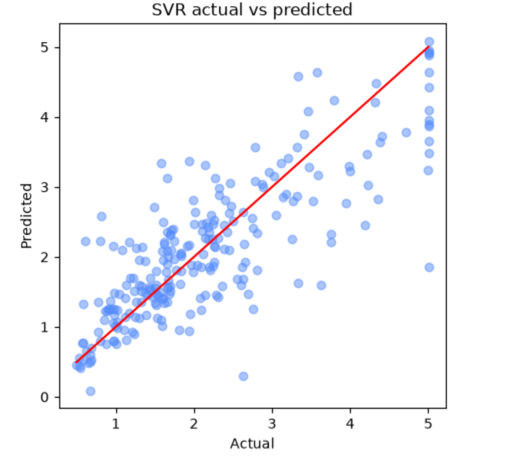

In [ ]:
# 문제 풀이 후 실행: 튜닝 모델 최종 평가와 시각화

tuned_svr = svr_grid_search.best_estimator_
tuned_pred_scaled = tuned_svr.predict(housing_X_test_scaled).reshape(-1, 1)
tuned_pred = housing_y_scaler.inverse_transform(tuned_pred_scaled).ravel()

print('튜닝 모델 RMSE:', root_mean_squared_error(housing_y_test, tuned_pred))
print('튜닝 모델 MAE:', mean_absolute_error(housing_y_test, tuned_pred))
print('튜닝 모델 R2:', r2_score(housing_y_test, tuned_pred))

plt.figure(figsize=(5, 5))
plt.scatter(housing_y_test, tuned_pred, alpha=0.5)
plt.plot([housing_y_test.min(), housing_y_test.max()], [housing_y_test.min(), housing_y_test.max()], color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('SVR actual vs predicted')
plt.show()
